Afrin Munshi 24EE10030, Advitiya Apurv 24EE10029

In [314]:
import numpy as np
import matplotlib.pyplot as plt
import math

Optimal solution is x=0

In [315]:
def f(x,k):
  return 0.5*np.sum(x[:-1]**2)+0.5*k*(x[-1])**2


In [316]:
def grad_f(x, k):
    sol = np.copy(x)
    sol[-1] = k * x[-1]
    return sol

In [317]:
def hessian_f_np(x, k):
    n = len(x)
    H = np.eye(n)
    H[-1, -1] = k
    return H

The smoothness paramenter, beta = K and the strongly convex parameter, alpha =1

In [318]:
def initial_guess(n, k, seed=42):

    rng = np.random.default_rng(seed)


    x0 = rng.multivariate_normal(mean=np.zeros(n), cov=np.eye(n))
    x0 *= 100
    return x0

Taking step size = 1/beta = 1/k

In [319]:
def grad_desc(x0,k,step_size,iterations):
  history=[]
  x=x0.copy()
  for i in range(iterations):
    x=x-step_size*grad_f(x,k)
    history.append(f(x,k))

  return x,np.array(history)

In [320]:
def accelerated_gradient_descent(x0, k, iterations):
    x = x0.copy()
    y = x0.copy()
    history = []
    for t in range(iterations):
        y_new=x-(1/k)*grad_f(x,k)
        x_new=y_new+((math.sqrt(k)-1)/(math.sqrt(k)+1))*(y_new-y)
        y=y_new
        x=x_new
        history.append(f(x, k))
    return x, np.array(history)


In [321]:
def momentum_descent(x0,k,mu,iterations):
    x = x0.copy()
    iters=[]
    iters.append(x.copy())
    history = []
    for i in range(1,iterations+1):
      if i==1:
        x=x0
        iters.append(x)
      else:
        x=x-(1/k)*grad_f(x,k)+mu*(x-iters[-2])
        iters.append(x)
      history.append(f(x,k))
    return x, np.array(history)

In [322]:
n=100
k=5
x0=initial_guess(n,k,67)
T=200
mu=0.8
step_size=1/k


In [323]:
x_gd, hist_gd = grad_desc(x0, k, step_size, T)
x_agd, hist_agd = accelerated_gradient_descent(x0, k, T)
x_mom, hist_mom = momentum_descent(x0, k, mu, T)
x_m2,hist_m2=momentum_descent(x0,k,0.4,T)
x_m3,hist_m3=momentum_descent(x0,k,0.6,T)

In [324]:
f0 = f(x0, k)
norm0 = np.linalg.norm(x0)

In [325]:
t = np.arange(1, T+1)

U3 = f0 * (k/(k-1))**(-t)

const = 1 + 1/(math.sqrt(k) - 1)
U5 = ((1 + k)/2) * norm0*norm0 * (const**(-t))

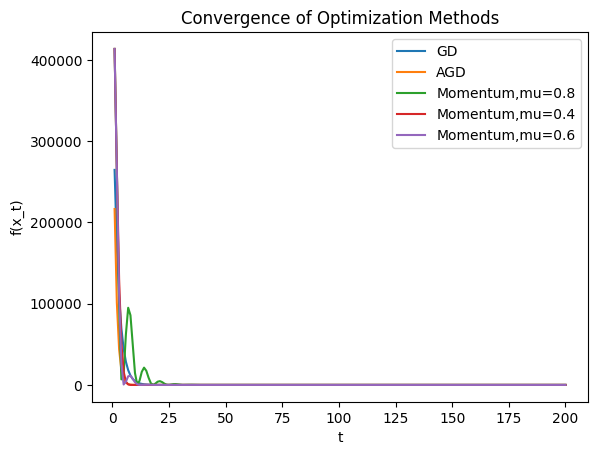

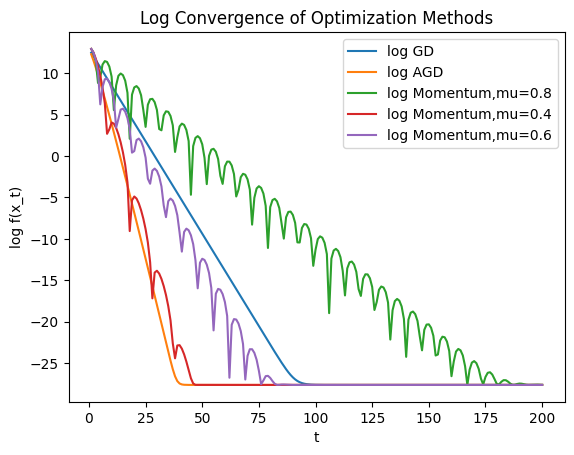

In [326]:
plt.figure()
plt.plot(t, hist_gd, label="GD")
plt.plot(t, hist_agd, label="AGD")
plt.plot(t, hist_mom, label="Momentum,mu=0.8")
plt.plot(t, hist_m2, label="Momentum,mu=0.4")
plt.plot(t, hist_m3, label="Momentum,mu=0.6")
plt.xlabel("t")
plt.ylabel("f(x_t)")
plt.title("Convergence of Optimization Methods")
plt.legend()
plt.show()


plt.figure()
plt.plot(t, np.log(hist_gd + 1e-12), label="log GD")
plt.plot(t, np.log(hist_agd + 1e-12), label="log AGD")
plt.plot(t, np.log(hist_mom + 1e-12), label="log Momentum,mu=0.8")
plt.plot(t, np.log(hist_m2 + 1e-12), label="log Momentum,mu=0.4")
plt.plot(t, np.log(hist_m3 + 1e-12), label="log Momentum,mu=0.6")
plt.xlabel("t")
plt.ylabel("log f(x_t)")
plt.title("Log Convergence of Optimization Methods")
plt.legend()
plt.show()

In [327]:
print(x_gd,x_agd,x_mom)

[-2.37952002e-18  7.97157961e-20 -4.65760901e-19 -1.56067682e-18
  5.95658130e-18  3.49322931e-18  2.13551185e-18  2.69737675e-18
 -4.59142304e-18  3.89019074e-18 -2.62622525e-18 -8.64093951e-19
  5.10067727e-18 -5.41120874e-18 -6.62101158e-18 -4.38026187e-18
  7.42686939e-18 -1.23709259e-19  3.16755321e-18 -2.07407896e-18
 -7.31866302e-18  1.32520023e-18  3.72300285e-18 -9.78234750e-19
  2.82752254e-18 -3.40332181e-18  2.71977074e-18  3.33533746e-18
 -3.49514137e-18 -2.17988174e-18 -1.13024021e-18 -7.42809877e-18
  9.46217237e-19 -1.62716672e-18 -1.03465824e-18 -1.26344194e-18
 -7.79265073e-18 -3.83264059e-18 -4.55955403e-18  3.95301807e-18
 -5.77303477e-19 -3.84728272e-18  1.70430606e-18 -4.01930094e-18
 -9.62654687e-19 -1.89340091e-18 -6.35034284e-18 -7.36241190e-18
 -2.11391096e-18 -6.05749321e-20  2.86878505e-18 -4.58121669e-18
 -2.03591978e-18 -5.23642698e-20 -1.20906579e-18 -3.01878735e-18
  4.10918587e-18  1.58456320e-18  5.69472530e-18  3.88109256e-18
  3.93386412e-18  1.52765